In [8]:
import numpy as np
np.bool = np.bool_ 
import pandas as pd
import os
from tqdm import tqdm

import mxnet as mx
from mxnet import gluon
from mxnet import autograd
from mxnet import image

import sys
sys.path.append('resuneta/src')
sys.path.append('decode/FracTAL_ResUNet/models/semanticsegmentation')
sys.path.append('decode/FracTAL_ResUNet/nn/loss')
sys.path.append('autogeobound/MXNet-ResUNeta/')

from bound_dist import get_distance, get_boundary
from FracTAL_ResUNet import FracTAL_ResUNet_cmtsk
#from ftnmt_loss import ftnmt_loss
from datasets import *

from sklearn.metrics import matthews_corrcoef

import random

import rasterio
from rasterio.enums import ColorInterp
from rasterio.features import shapes
from scipy import ndimage

import matplotlib.pyplot as plt
%matplotlib inline

import higra as hg
import torch
import pickle

import itertools

import imageio.v3 as imageio
from skimage.color import label2rgb
import cv2
from skimage.segmentation import mark_boundaries
from skimage.segmentation import find_boundaries

from shapely.geometry import shape
import shapely
from shapely import Polygon, orient_polygons

import ast

import glob

In [2]:
import random
np.random.seed(0)
random.seed(0)

data = pd.read_csv('inference_data/inference_data.csv')
image_filenames = data[data["num_cultivated_pixels"] > 0]["image_filename"].tolist() # images that have at least one cultivated pixel
image_filenames = random.sample(image_filenames, 10)

In [3]:
n_filters = 32
depth = 6
n_classes = 1
ctx = [mx.gpu(0), mx.gpu(1), mx.gpu(2), mx.gpu(3)]
model = FracTAL_ResUNet_cmtsk(nfilters_init=n_filters, depth=depth, NClasses=n_classes)
model.load_parameters('experiments/8m-resolution/US/fractal-resunet_NAIP_nfilter-32_depth-6_bs-80_lr-0.001/model-20epoch.params', ctx=ctx)

depth:= 0, nfilters: 32, nheads::8, widths::1
depth:= 1, nfilters: 64, nheads::16, widths::1
depth:= 2, nfilters: 128, nheads::32, widths::1
depth:= 3, nfilters: 256, nheads::64, widths::1
depth:= 4, nfilters: 512, nheads::128, widths::1
depth:= 5, nfilters: 1024, nheads::256, widths::1
depth:= 6, nfilters: 512, nheads::256, widths::1
depth:= 7, nfilters: 256, nheads::128, widths::1
depth:= 8, nfilters: 128, nheads::64, widths::1
depth:= 9, nfilters: 64, nheads::32, widths::1
depth:= 10, nfilters: 32, nheads::16, widths::1


[17:45:48] /work/mxnet/src/base.cc:79: cuDNN lib mismatch: linked-against version 8200 != compiled-against version 8500.  Set MXNET_CUDNN_LIB_CHECKING=0 to quiet this warning.


In [9]:
topleft_indices1 = list(itertools.product([0, 512, 1024, 1536], [0, 512, 1024, 1536]))
topleft_indices2 = list(itertools.product([0, 128, 256], [0, 128, 256]))
topleft_indices = [(i1[0]+i2[0], i1[1]+i2[1]) for i2 in topleft_indices2 for i1 in topleft_indices1]

count = np.zeros((2048, 2048))
for x, y in topleft_indices:
    count[x:x+256, y:y+256] += np.ones((256, 256))

for image_filename in tqdm(image_filenames):
    image_number = image_filename[-9:-4]
    image = imageio.imread(image_filename)
    image = np.moveaxis(image, -1, 0)

    image_patches = mx.nd.array(np.stack([image[:, x:x+256, y:y+256] for x, y in topleft_indices], axis=0))
    image_patches_split = gluon.utils.split_and_load(image_patches, ctx)
    bound_patches = []
    for image_patches_split_i in image_patches_split:
        _, bound_patches_split_i, _ = model(image_patches_split_i)
        bound_patches_split_i = np.squeeze(bound_patches_split_i.asnumpy())
        bound_patches.append(bound_patches_split_i)
    bound_patches = np.concatenate(bound_patches)    
    
    bound = np.zeros((2048, 2048))
    for i in range(len(topleft_indices)):
        x, y = topleft_indices[i]
        bound_crop = bound_patches[i]
        bound[x:x+256, y:y+256] += bound_crop
    bound /= count

    np.save(f"testing/pipeline-test/ml_preds/{image_number}.npy", bound)

100%|██████████| 10/10 [00:13<00:00,  1.33s/it]


# Compare outputs against using fewer than 4 nodes

In [7]:
n_filters = 32
depth = 6
n_classes = 1
ctx = [mx.gpu(0), mx.gpu(1)]
model = FracTAL_ResUNet_cmtsk(nfilters_init=n_filters, depth=depth, NClasses=n_classes)
model.load_parameters('experiments/8m-resolution/US/fractal-resunet_NAIP_nfilter-32_depth-6_bs-80_lr-0.001/model-20epoch.params', ctx=ctx)

topleft_indices1 = list(itertools.product([0, 512, 1024, 1536], [0, 512, 1024, 1536]))
topleft_indices2 = list(itertools.product([0, 128, 256], [0, 128, 256]))
topleft_indices = [(i1[0]+i2[0], i1[1]+i2[1]) for i2 in topleft_indices2 for i1 in topleft_indices1]

count = np.zeros((2048, 2048))
for x, y in topleft_indices:
    count[x:x+256, y:y+256] += np.ones((256, 256))

for image_filename in tqdm(image_filenames[:3]):
    image_number = image_filename[-9:-4]
    image = imageio.imread(image_filename)
    image = np.moveaxis(image, -1, 0)

    image_patches = mx.nd.array(np.stack([image[:, x:x+256, y:y+256] for x, y in topleft_indices], axis=0))
    image_patches_split = gluon.utils.split_and_load(image_patches, ctx)
    bound_patches = []
    for image_patches_split_i in image_patches_split:
        _, bound_patches_split_i, _ = model(image_patches_split_i)
        bound_patches_split_i = np.squeeze(bound_patches_split_i.asnumpy())
        bound_patches.append(bound_patches_split_i)
    bound_patches = np.concatenate(bound_patches)    
    
    bound = np.zeros((2048, 2048))
    for i in range(len(topleft_indices)):
        x, y = topleft_indices[i]
        bound_crop = bound_patches[i]
        bound[x:x+256, y:y+256] += bound_crop
    bound /= count

    np.save(f"testing/outputs-images-method3/{image_number}.npy", bound)

depth:= 0, nfilters: 32, nheads::8, widths::1
depth:= 1, nfilters: 64, nheads::16, widths::1
depth:= 2, nfilters: 128, nheads::32, widths::1
depth:= 3, nfilters: 256, nheads::64, widths::1
depth:= 4, nfilters: 512, nheads::128, widths::1
depth:= 5, nfilters: 1024, nheads::256, widths::1
depth:= 6, nfilters: 512, nheads::256, widths::1
depth:= 7, nfilters: 256, nheads::128, widths::1
depth:= 8, nfilters: 128, nheads::64, widths::1
depth:= 9, nfilters: 64, nheads::32, widths::1
depth:= 10, nfilters: 32, nheads::16, widths::1


[20:43:52] /work/mxnet/src/operator/nn/./cudnn/./cudnn_algoreg-inl.h:96: Running performance tests to find the best convolution algorithm, this can take a while... (set the environment variable MXNET_CUDNN_AUTOTUNE_DEFAULT to 0 to disable)
100%|██████████| 3/3 [00:19<00:00,  6.47s/it]


# Compare outputs against Method 1

In [8]:
n_filters = 32
depth = 6
n_classes = 1
ctx = mx.gpu(2)
model = FracTAL_ResUNet_cmtsk(nfilters_init=n_filters, depth=depth, NClasses=n_classes)
model.load_parameters('experiments/8m-resolution/US/fractal-resunet_NAIP_nfilter-32_depth-6_bs-80_lr-0.001/model-20epoch.params', ctx=ctx)

def predict_boundaries_512(image):
    bound = np.zeros((512, 512))
    count = np.zeros((512, 512))
    topleft_indices = list(itertools.product([0, 128, 256], [0, 128, 256]))
    for topleft_index in topleft_indices:
        x1, x2, y1, y2 = topleft_index[0], topleft_index[0]+256, topleft_index[1], topleft_index[1]+256
        image_crop = mx.nd.array(image[:, :, x1:x2, y1:y2])
        _, bound_crop, _ = model(image_crop.as_in_context(ctx))
        bound[x1:x2, y1:y2] += bound_crop[0][0].asnumpy()
        count[x1:x2, y1:y2] += np.ones((256, 256))
    bound /= count
    return bound

depth:= 0, nfilters: 32, nheads::8, widths::1
depth:= 1, nfilters: 64, nheads::16, widths::1
depth:= 2, nfilters: 128, nheads::32, widths::1
depth:= 3, nfilters: 256, nheads::64, widths::1
depth:= 4, nfilters: 512, nheads::128, widths::1
depth:= 5, nfilters: 1024, nheads::256, widths::1
depth:= 6, nfilters: 512, nheads::256, widths::1
depth:= 7, nfilters: 256, nheads::128, widths::1
depth:= 8, nfilters: 128, nheads::64, widths::1
depth:= 9, nfilters: 64, nheads::32, widths::1
depth:= 10, nfilters: 32, nheads::16, widths::1


In [9]:
T_values = [0.003, 0.005, 0.02, 0.04, 0.09, 0.19]
graph = hg.get_8_adjacency_graph((512, 512))
topleft_indices = list(itertools.product([0, 512, 1024, 1536], [0, 512, 1024, 1536]))

image_border = np.ones((2048, 2048))
image_border[1:-1, 1:-1] = 0

image_bottom_right_corner = np.zeros((2048, 2048))
image_bottom_right_corner[512:, 512:] = 1

for image_filename in tqdm(image_filenames[:3]):
    image_number = image_filename[-9:-4]
    
    src = rasterio.open(image_filename)
    transform = src.transform
    
    image = imageio.imread(image_filename)
    image = np.moveaxis(image, -1, 0)[np.newaxis, :]

    CDL_filename = image_filename.replace("images", "CDL")
    CDL = imageio.imread(CDL_filename)

    
    trees_list = []
    altitudes_list = []
    bbox_coords_list = []
    output = np.zeros((2048, 2048))
    for topleft_index in topleft_indices:
        x1, x2, y1, y2 = topleft_index[0], topleft_index[0]+512, topleft_index[1], topleft_index[1]+512
        bound = predict_boundaries_512(image[:, :, x1:x2, y1:y2])
        output[x1:x2, y1:y2] = bound

    np.save(f"testing/outputs-images-method1/{image_number}.npy", output)

[20:44:03] /work/mxnet/src/operator/nn/./cudnn/./cudnn_algoreg-inl.h:96: Running performance tests to find the best convolution algorithm, this can take a while... (set the environment variable MXNET_CUDNN_AUTOTUNE_DEFAULT to 0 to disable)
100%|██████████| 3/3 [00:46<00:00, 15.49s/it]


# Comparison - differences may be due to different batch sizes

  0%|          | 0/3 [00:00<?, ?it/s]

0.0006563961505889893
0.0006338655948638916
0.0003833770751953125


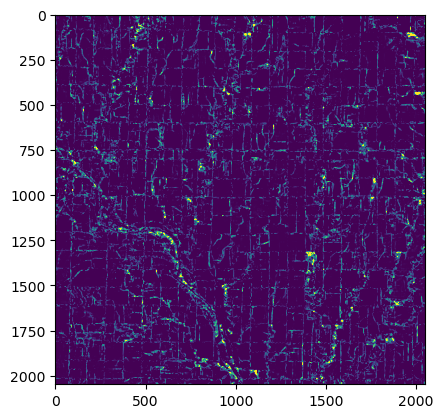

 33%|███▎      | 1/3 [00:00<00:00,  3.25it/s]

0.0006104707717895508
0.0005033612251281738
0.0002008676528930664


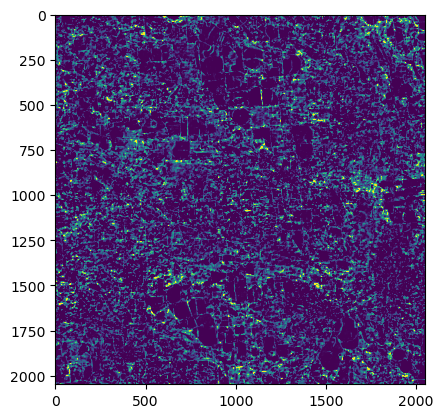

 67%|██████▋   | 2/3 [00:00<00:00,  3.20it/s]

0.0005862712860107422
0.0005835890769958496
0.00024497509002685547


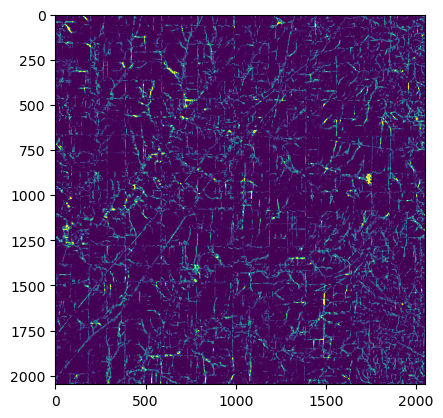

100%|██████████| 3/3 [00:00<00:00,  3.18it/s]


In [16]:
for image_filename in tqdm(image_filenames[:3]):
    image_number = image_filename[-9:-4]
    output1 = np.load(f"testing/outputs-images-method1/{image_number}.npy")
    output2 = np.load(f"testing/outputs-images-method2/{image_number}.npy")
    output3 = np.load(f"testing/outputs-images-method3/{image_number}.npy")
    #print(np.array_equal(output1, output2))
    print(np.max(np.abs(output1 - output2)))
    print(np.max(np.abs(output1 - output3)))
    print(np.max(np.abs(output2 - output3)))
    plt.imshow(output2-output1, vmin=0, vmax=0.0001)
    plt.show()